In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [44]:
df_temperatura = pd.read_csv("./celsius_a_fahrenheit.csv")

print(df_temperatura.head())

   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0


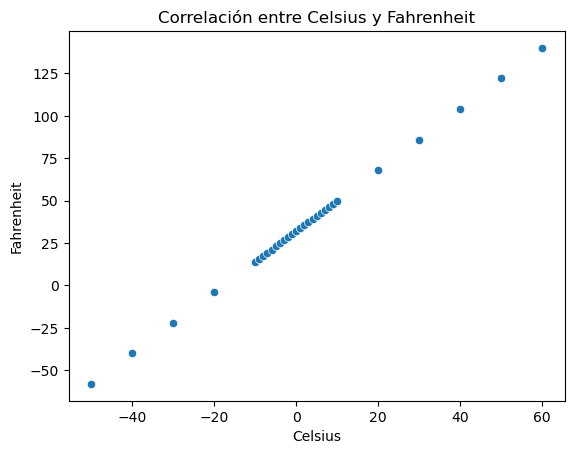

In [45]:
sns.scatterplot(x="Celsius", y="Fahrenheit", data=df_temperatura)
plt.title("Correlación entre Celsius y Fahrenheit")
plt.show()

In [46]:
X_train = np.array(df_temperatura["Celsius"], dtype=float)
Y_train = np.array(df_temperatura["Fahrenheit"], dtype=float)

print("Creando el modelo")
model = tf.keras.Sequential([tf.keras.layers.Dense(units=1, input_shape=[1])])
model.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")
hist1 = model.fit(X_train, Y_train, epochs=100, verbose=False)

Creando el modelo


In [47]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)

modelo = tf.keras.Sequential([oculta1, oculta2, salida])
modelo.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")

Entrenando el modelo parte 2
Epoch 1/100
1/1 [==============================] - 0s 437ms/step - loss: 5246.8965
Epoch 2/100
1/1 [==============================] - 0s 3ms/step - loss: 11076.4531
Epoch 3/100
1/1 [==============================] - 0s 1ms/step - loss: 3381.6150
Epoch 4/100
1/1 [==============================] - 0s 3ms/step - loss: 7490.2812
Epoch 5/100
1/1 [==============================] - 0s 2ms/step - loss: 14689.5225
Epoch 6/100
1/1 [==============================] - 0s 5ms/step - loss: 453.6898
Epoch 7/100
1/1 [==============================] - 0s 2ms/step - loss: 3480.2336
Epoch 8/100
1/1 [==============================] - 0s 2ms/step - loss: 2499.7297
Epoch 9/100
1/1 [==============================] - 0s 4ms/step - loss: 518.7884
Epoch 10/100
1/1 [==============================] - 0s 1ms/step - loss: 1570.1466
Epoch 11/100
1/1 [==============================] - 0s 1ms/step - loss: 2050.7700
Epoch 12/100
1/1 [==============================] - 0s 4ms/step - loss: 137.

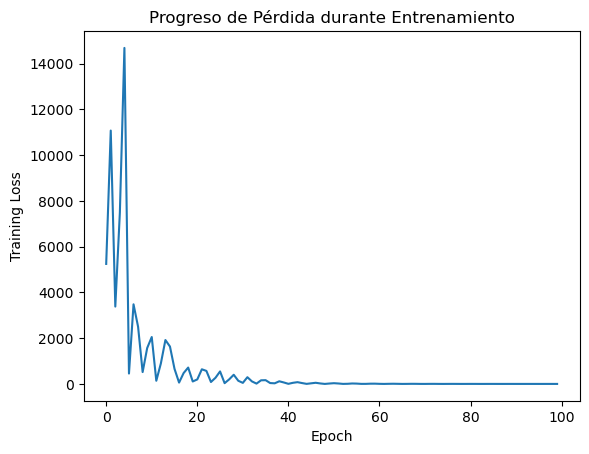

In [48]:
print("Entrenando el modelo parte 2")
epochs_hist = modelo.fit(X_train, Y_train, epochs=100)

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

print("Keys: ", epochs_hist.history.keys())

plt.plot(epochs_hist.history["loss"])
plt.title("Progreso de Pérdida durante Entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.show()

Temperatura predicha : [[211.5402]]
Temperatura ecuación : 212.0


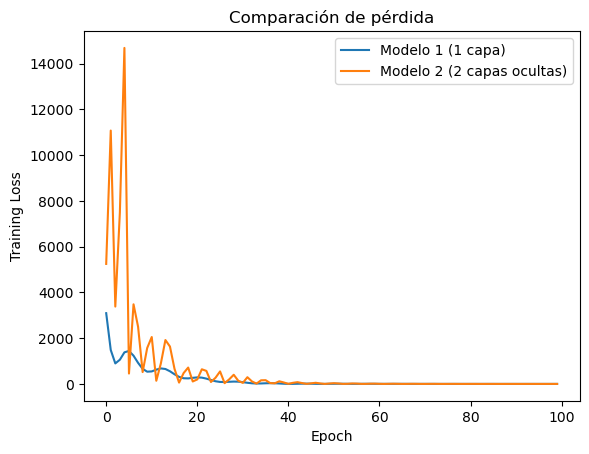

In [49]:
Temp_C = 100
Temp_F_pred = modelo.predict(np.array([[Temp_C]]), verbose=0)
Temp_F_real = 9 / 5 * Temp_C + 32

print("Temperatura predicha : " + str(Temp_F_pred))
print("Temperatura ecuación : " + str(Temp_F_real))

# Comparación de pérdidas
plt.plot(hist1.history["loss"], label="Modelo 1 (1 capa)")
plt.plot(epochs_hist.history["loss"], label="Modelo 2 (2 capas ocultas)")
plt.title("Comparación de pérdida")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

Predicción con ReLU  : 35.600002
Valor real (fórmula) : 212.0


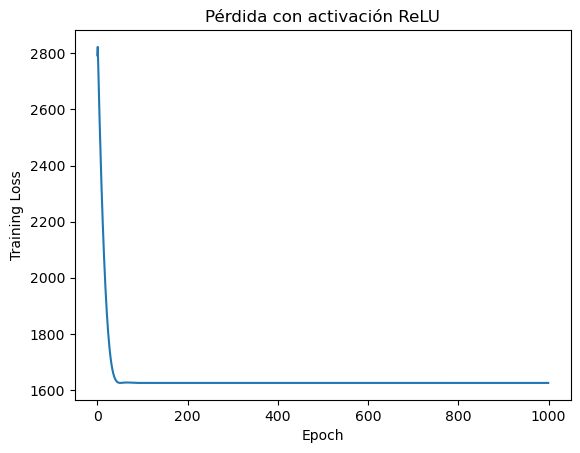

In [50]:
oculta1_relu = tf.keras.layers.Dense(units=3, input_shape=[1], activation="relu")
oculta2_relu = tf.keras.layers.Dense(units=3, activation="relu")
salida_relu = tf.keras.layers.Dense(units=1)

modelo_relu = tf.keras.Sequential([oculta1_relu, oculta2_relu, salida_relu])
modelo_relu.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss="mean_squared_error")

hist_relu = modelo_relu.fit(X_train, Y_train, epochs=1000, verbose=False)

pred_relu = modelo_relu.predict(np.array([[100]]), verbose=0)
print("Predicción con ReLU  :", pred_relu[0][0])
print("Valor real (fórmula) :", 9 / 5 * 100 + 32)

plt.plot(hist_relu.history["loss"])
plt.title("Pérdida con activación ReLU")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.show()

## Análisis y Discusión de Preguntas

**1.**
Adam sirve para ajustar automáticamente la tasa de aprendizaje, siendo el más rápido y estable. Por otro lado, SGD es el más simple pero aprende más lento y puede atascarse. Y finalmente, RMSProp adapta la tasa según el historial reciente. Cambiar a SGD requeriría más epochs para converger, mientras que RMSProp daría resultados similares a Adam.

**2.**
El mean_squared_error se utiliza para medir el promedio de errores al cuadrado, penalizando más los errores grandes. Alternativas como mean_absolute_error son menos sensibles a valores atípicos, y huber combina ambas siendo más robusta. Dependiendo de tu elección de cuál de éstos utilizar, terminaría afectando qué tan agresivamente el modelo corrige sus errores.

**3.**
La pérdida se estabiliza alrededor de la epoch 50-70 en el Modelo 1 y cerca de la 30-50 en el Modelo 2, por lo que las 100 epochs utilizadas son suficientes.

**4.**
Las epochs determinan cuántas veces el modelo revisa los datos para ajustar sus pesos, usar pocas genera underfitting y demasiadas sería overfitting. El número adecuado es donde la pérdida deja de disminuir.

**5.**
Las capas Dense usan activación lineal por defecto, adecuada para regresión ya que la salida puede ser cualquier número. Es posible cambiarla a ReLU agregando activation='relu' en las capas ocultas, que solo activa neuronas con valores positivos. Sin embargo, al implementarla, podemos observar que el modelo no converge correctamente, incluso después de 1000 epochs, prediciendo 35.6°F en lugar de 212°F. Esto se debe a que ReLU desactiva neuronas con valores negativos, y como los datos de entrenamiento incluyen temperaturas bajo cero, el modelo pierde información clave. Esto confirma que la activación lineal es más adecuada para este tipo de problema de regresión.

